# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# Create our raw dataset

In [2]:
data = {
    "Customer_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
                    111, 112, 113, 114, 115],

    "Age": [25, 34, np.nan, 45, 29, 52, 41, 38, np.nan, 31,
            27, 150, 36, 44, 33],

    "Gender": ["Male", "Female", "Female", "Male", "Female",
               "Male", "Male", np.nan, "Female", "Male",
               "Female", "Male", "Female", "Male", "Female"],

    "City": ["Mumbai", "Pune", "Mumbai", "Delhi", "Pune",
             "Mumbai", "Delhi", "Pune", "Mumbai", "Delhi",
             "Pune", "Mumbai", "Delhi", "Pune", "Mumbai"],

    "Annual_Income": [350000, 500000, 420000, 650000, np.nan,
                      800000, 720000, 550000, 480000, 610000,
                      390000, 4500000, 580000, 690000, 510000],

    "Purchase_Count": [5, 8, 6, 10, 4, 12, 9, 7, 5, 11,
                       3, 100, 8, 10, 6]
}

df = pd.DataFrame(data)

df

,Customer_ID,Age,Gender,City,Annual_Income,Purchase_Count
0,101,25.0,Male,Mumbai,350000.0,5
1,102,34.0,Female,Pune,500000.0,8
2,103,NaN,Female,Mumbai,420000.0,6
3,104,45.0,Male,Delhi,650000.0,10
4,105,29.0,Female,Pune,NaN,4
5,106,52.0,Male,Mumbai,800000.0,12
6,107,41.0,Male,Delhi,720000.0,9
7,108,38.0,NaN,Pune,550000.0,7
8,109,NaN,Female,Mumbai,480000.0,5
9,110,31.0,Male,Delhi,610000.0,11


# Understand the raw data

In [3]:
df.head(10)

,Customer_ID,Age,Gender,City,Annual_Income,Purchase_Count
0,101,25.0,Male,Mumbai,350000.0,5
1,102,34.0,Female,Pune,500000.0,8
2,103,NaN,Female,Mumbai,420000.0,6
3,104,45.0,Male,Delhi,650000.0,10
4,105,29.0,Female,Pune,NaN,4
5,106,52.0,Male,Mumbai,800000.0,12
6,107,41.0,Male,Delhi,720000.0,9
7,108,38.0,NaN,Pune,550000.0,7
8,109,NaN,Female,Mumbai,480000.0,5
9,110,31.0,Male,Delhi,610000.0,11


In [4]:
df.shape

(15, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     15 non-null     int64  
 1   Age             13 non-null     float64
 2   Gender          14 non-null     object 
 3   City            15 non-null     object 
 4   Annual_Income   14 non-null     float64
 5   Purchase_Count  15 non-null     int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 852.0+ bytes


In [6]:
df.isnull().sum()

,0
Customer_ID,0
Age,2
Gender,1
City,0
Annual_Income,1
Purchase_Count,0


# Find duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


# Handle Missing Values

In [9]:
df.isnull().sum()

,0
Customer_ID,0
Age,2
Gender,1
City,0
Annual_Income,1
Purchase_Count,0


# Median

In [10]:
df["Age"] = df["Age"].fillna(df["Age"].median())

# For Income

In [11]:
df["Annual_Income"] = df["Annual_Income"].fillna(
    df["Annual_Income"].median()
)

# For Gender

In [12]:
df["Gender"] = df["Gender"].fillna(
    df["Gender"].mode()[0]
)

In [13]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
City,0
Annual_Income,0
Purchase_Count,0


# Detect Outliers

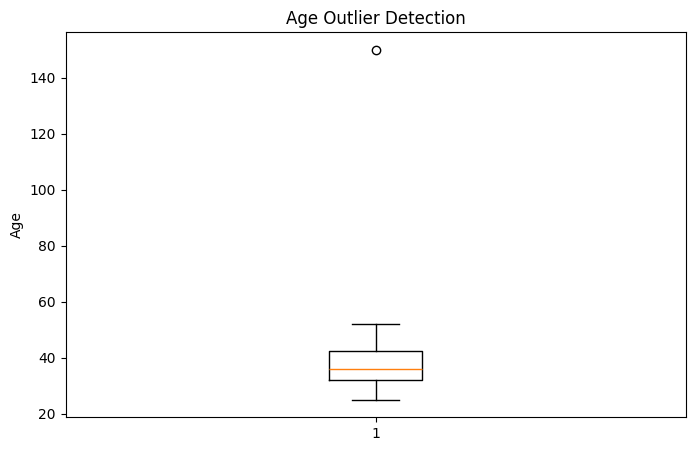

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df["Age"])
plt.title("Age Outlier Detection")
plt.ylabel("Age")
plt.show()

# Use IQR to detect outliers

In [15]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: 16.25
Upper bound: 58.25


# Find Outliers

In [16]:
age_outliers = df[
    (df["Age"] < lower_bound) |
    (df["Age"] > upper_bound)
]

age_outliers

,Customer_ID,Age,Gender,City,Annual_Income,Purchase_Count
11,112,150.0,Male,Mumbai,4500000.0,100


# Fix the age outlier

In [17]:
median_age = df["Age"].median()

df.loc[df["Age"] > 100, "Age"] = median_age

In [18]:
df['Age'].max()

52.0

# Handle categorical data

In [19]:
df = pd.get_dummies(
    df,
    columns=["Gender"],
    dtype=int
)

In [21]:
df.head()

,Customer_ID,Age,City,Annual_Income,Purchase_Count,Gender_Female,Gender_Male
0,101,25.0,Mumbai,350000.0,5,0,1
1,102,34.0,Pune,500000.0,8,1,0
2,103,36.0,Mumbai,420000.0,6,1,0
3,104,45.0,Delhi,650000.0,10,0,1
4,105,29.0,Pune,565000.0,4,1,0


# Standardize numerical data

In [22]:
numeric_columns = [
    "Age",
    "Annual_Income",
    "Purchase_Count"
]

# Create scaler

In [23]:
scaler = StandardScaler()

In [24]:
df[numeric_columns] = scaler.fit_transform(
    df[numeric_columns]
)

In [25]:
df.head()

,Customer_ID,Age,City,Annual_Income,Purchase_Count,Gender_Female,Gender_Male
0,101,-1.618380,Mumbai,-0.475489,-0.370186,0,1
1,102,-0.317896,Pune,-0.324059,-0.241051,1,0
2,103,-0.028900,Mumbai,-0.404822,-0.327141,1,0
3,104,1.271584,Delhi,-0.172630,-0.154961,0,1
4,105,-1.040387,Pune,-0.258440,-0.413230,1,0


# Before vs After Data Quality Check

# Check missing values

In [26]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Customer_ID       0
Age               0
City              0
Annual_Income     0
Purchase_Count    0
Gender_Female     0
Gender_Male       0
dtype: int64


# Check duplicates

In [27]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# Check the final dataset

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     15 non-null     int64  
 1   Age             15 non-null     float64
 2   City            15 non-null     object 
 3   Annual_Income   15 non-null     float64
 4   Purchase_Count  15 non-null     float64
 5   Gender_Female   15 non-null     int64  
 6   Gender_Male     15 non-null     int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 972.0+ bytes


In [29]:
df.head()

,Customer_ID,Age,City,Annual_Income,Purchase_Count,Gender_Female,Gender_Male
0,101,-1.618380,Mumbai,-0.475489,-0.370186,0,1
1,102,-0.317896,Pune,-0.324059,-0.241051,1,0
2,103,-0.028900,Mumbai,-0.404822,-0.327141,1,0
3,104,1.271584,Delhi,-0.172630,-0.154961,0,1
4,105,-1.040387,Pune,-0.258440,-0.413230,1,0


# One important thing: Customer_ID

We should NOT standardize Customer_ID.

It's an identifier, not a meaningful numerical feature.

Fortunately, in our code we only standardized:

In [30]:
numeric_columns = [
    "Age",
    "Annual_Income",
    "Purchase_Count"
]

# Save the cleaned dataset

In [31]:
df.to_csv(
    "customer_data_cleaned.csv",
    index=False
)

In [32]:
import os

print("File created:", os.path.exists("customer_data_cleaned.csv"))

File created: True


# Create a Cleaning Summary

## Data Cleaning Summary

The raw customer dataset was cleaned and preprocessed using Python.

### Cleaning steps performed:

- Missing numerical values were replaced using the median.
- Missing categorical values were replaced using the mode.
- Duplicate records were checked.
- Extreme age values were identified and corrected.
- Categorical gender values were converted using one-hot encoding.
- Numerical features were standardized using StandardScaler.
- Customer_ID was retained as an identifier and was not scaled.
- The final cleaned dataset was exported as CSV.

# Create a Final Quality Report

In [33]:
print("========== FINAL DATA QUALITY REPORT ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nColumn data types:")
print(df.dtypes)

========== FINAL DATA QUALITY REPORT ==========
Rows: 15
Columns: 7
Missing values: 0
Duplicate rows: 0

Column data types:
Customer_ID         int64
Age               float64
City               object
Annual_Income     float64
Purchase_Count    float64
Gender_Female       int64
Gender_Male         int64
dtype: object


# Before/After Summary

In [34]:
summary = {
    "Original Rows": 15,
    "Original Columns": 6,
    "Final Rows": df.shape[0],
    "Final Columns": df.shape[1],
    "Missing Values After Cleaning": df.isnull().sum().sum(),
    "Duplicate Rows After Cleaning": df.duplicated().sum()
}

summary_df = pd.DataFrame([summary])

summary_df

,Original Rows,Original Columns,Final Rows,Final Columns,Missing Values After Cleaning,Duplicate Rows After Cleaning
0,15,6,15,7,0,0


In [35]:
summary_df.to_csv("data_cleaning_summary.csv", index=False)